# Bank GoodCredit — Credit Risk Modeling and Scorecard Analysis

## Business objective

Bank GoodCredit wants to estimate the credit worthiness of current credit-card customers and reduce credit-default risk.

**Target**

- `Bad_label = 0` → good credit history
- `Bad_label = 1` → bad credit history (30+ DPD)

The supplied project brief reports a **benchmark Gini of 37.9%** and asks for:

1. Data exploration insights and decisions
2. A feature matrix with selected features and gain
3. Model evaluation using **Gini and rank ordering**

This notebook keeps those requirements at the center, while strengthening the credit-risk methodology with:

- granular DPD-bucket features;
- WOE / Information Value analysis and a WOE Logistic scorecard reference model;
- KS statistic;
- a tuned gradient-boosting model;
- cross-validated final-model discrimination;
- out-of-time validation when the reference-date coverage supports it;
- Population Stability Index (PSI) on model scores;
- explicit benchmark-gap and next-step analysis.

The purpose is not to use the largest number of algorithms. The purpose is to produce a defensible credit-risk modeling workflow using only transformations supported by the supplied fields.

## 1. Imports and reproducibility

In [1]:
from pathlib import Path
import re
import gc
import warnings
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
)
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
N_JOBS = 2
TEST_SIZE = 0.20
CV_FOLDS = 3
FINAL_CV_FOLDS = 5
BENCHMARK_GINI = 0.379

# Tuning budget for the gradient-boosting model.
BOOSTING_SEARCH_ITER = 8

DATA_DIR = Path(".")

FILE_CANDIDATES = {
    "demographics": [
        "Cust_Demographics_FULL.csv",
        "Cust_Demographics_Full.csv",
        "Customer_Demographics.csv",
    ],
    "account": [
        "Cust_Account_Full.csv",
        "Cust_Account_FULL.csv",
        "Account_Customer.csv",
    ],
    "enquiry": [
        "Cust_Enquiry_full(1).csv",
        "Cust_Enquiry_FULL.csv",
        "Cust_enquiry_full.csv",
        "Customer_Enquiry.csv",
    ],
}

def resolve_file(candidates):
    for folder in [DATA_DIR, Path("/mnt/data")]:
        for name in candidates:
            p = folder / name
            if p.exists():
                return p
    raise FileNotFoundError(
        "Could not find any of these files:\n" + "\n".join(candidates)
        + "\nSet DATA_DIR to the folder containing the three CSV files."
    )

paths = {k: resolve_file(v) for k, v in FILE_CANDIDATES.items()}
paths

{'demographics': WindowsPath('Cust_Demographics_FULL.csv'),
 'account': WindowsPath('Cust_Account_Full.csv'),
 'enquiry': WindowsPath('Cust_Enquiry_FULL.csv')}

## 2. Load and validate the three source tables

The exported source files are semicolon-delimited. The three tables have different grains:

- demographics → one row per customer;
- account → multiple historical account/payment records per customer;
- enquiry → multiple enquiry records per customer.

The model therefore cannot be trained directly on the raw tables. Account and enquiry histories must first be summarized to customer level.

In [2]:
def load_csv(path):
    return pd.read_csv(path, sep=";", low_memory=False)

demo = load_csv(paths["demographics"])
acct = load_csv(paths["account"])
enq = load_csv(paths["enquiry"])

for df in (demo, acct, enq):
    df.columns = [str(c).strip() for c in df.columns]

print("Demographics:", demo.shape)
print("Account     :", acct.shape)
print("Enquiry     :", enq.shape)

Demographics: (23896, 83)
Account     : (186329, 21)
Enquiry     : (413188, 6)


In [3]:
required_demo = {"dt_opened", "customer_no", "Bad_label"}
required_acct = {
    "dt_opened", "customer_no", "acct_type", "owner_indic", "opened_dt",
    "last_paymt_dt", "cur_balance_amt", "amt_past_due",
    "paymenthistory1", "paymenthistory2", "creditlimit", "cashlimit"
}
required_enq = {"dt_opened", "customer_no", "enquiry_dt", "enq_purpose", "enq_amt"}

for name, df, req in [
    ("Demographics", demo, required_demo),
    ("Account", acct, required_acct),
    ("Enquiry", enq, required_enq),
]:
    missing = sorted(req - set(df.columns))
    if missing:
        raise ValueError(f"{name} is missing required columns: {missing}")

print("Schema validation passed.")

Schema validation passed.


## 3. Data-quality audit and target analysis

In [4]:
audit = pd.DataFrame({
    "table": ["Demographics", "Account", "Enquiry"],
    "rows": [len(demo), len(acct), len(enq)],
    "columns": [demo.shape[1], acct.shape[1], enq.shape[1]],
    "unique_customers": [
        demo["customer_no"].nunique(),
        acct["customer_no"].nunique(),
        enq["customer_no"].nunique(),
    ],
    "missing_customer_no": [
        demo["customer_no"].isna().sum(),
        acct["customer_no"].isna().sum(),
        enq["customer_no"].isna().sum(),
    ],
    "exact_duplicate_rows": [
        demo.duplicated().sum(),
        acct.duplicated().sum(),
        enq.duplicated().sum(),
    ],
})
audit

,table,rows,columns,unique_customers,missing_customer_no,exact_duplicate_rows
0,Demographics,23896,83,23896,0,0
1,Account,186329,21,23896,0,2401
2,Enquiry,413188,6,23896,0,13827


In [5]:
target_summary = (
    demo["Bad_label"]
    .value_counts(dropna=False)
    .rename_axis("Bad_label")
    .to_frame("count")
)
target_summary["percentage"] = 100 * target_summary["count"] / len(demo)
target_summary

,count,percentage
Bad_label,,
0,22892,95.7985
1,1004,4.2015


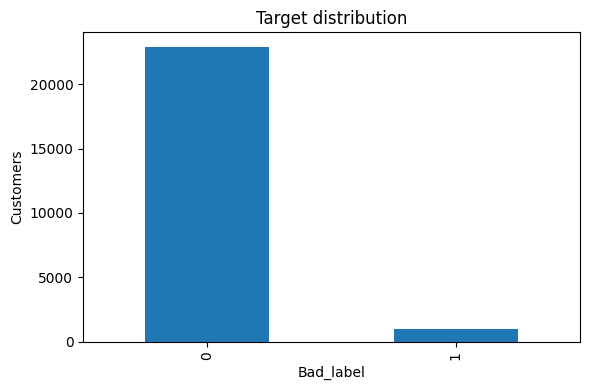

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
demo["Bad_label"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Target distribution")
ax.set_xlabel("Bad_label")
ax.set_ylabel("Customers")
plt.tight_layout()
plt.show()

In [7]:
demo_ids = set(demo["customer_no"].dropna().astype(int))
acct_ids = set(acct["customer_no"].dropna().astype(int))
enq_ids = set(enq["customer_no"].dropna().astype(int))

coverage = pd.DataFrame({
    "comparison": [
        "Demographics customers in Account",
        "Demographics customers in Enquiry",
        "Customers present in all three tables",
    ],
    "count": [
        len(demo_ids & acct_ids),
        len(demo_ids & enq_ids),
        len(demo_ids & acct_ids & enq_ids),
    ],
})
coverage["pct_of_demographics"] = 100 * coverage["count"] / len(demo_ids)
coverage

,comparison,count,pct_of_demographics
0,Demographics customers in Account,23896,100.0000
1,Demographics customers in Enquiry,23896,100.0000
2,Customers present in all three tables,23896,100.0000


In [8]:
def missing_report(df, table_name, top_n=20):
    out = (
        df.isna().mean().mul(100)
        .sort_values(ascending=False)
        .head(top_n)
        .rename("missing_pct")
        .to_frame()
    )
    out.insert(0, "table", table_name)
    return out

pd.concat([
    missing_report(demo, "Demographics"),
    missing_report(acct, "Account"),
    missing_report(enq, "Enquiry")
])

,table,missing_pct
feature_61,Demographics,99.9623
feature_74,Demographics,99.9289
feature_18,Demographics,99.9247
feature_10,Demographics,99.7866
feature_49,Demographics,99.5648
feature_17,Demographics,95.7022
feature_8,Demographics,94.7230
feature_9,Demographics,94.7230
feature_57,Demographics,89.9858
feature_73,Demographics,87.6758


### Data-quality decisions

- `customer_no` is a join key only and is excluded from modeling.
- Exact duplicate historical records are removed before aggregation so duplicated exports do not receive extra weight.
- Missing-value imputation is fitted on training data only.
- Anonymized demographic variables are not assigned invented business meanings.
- Identifier-like high-cardinality text fields are excluded.
- Historical account/enquiry dates are checked against the customer reference date to detect possible post-reference leakage.

In [9]:
acct = acct.drop_duplicates().reset_index(drop=True)
enq = enq.drop_duplicates().reset_index(drop=True)

if demo["customer_no"].duplicated().any():
    demo = demo.drop_duplicates(subset=["customer_no"], keep="last").reset_index(drop=True)

gc.collect()

53

## 4. Date preparation and leakage checks

In [10]:
DATE_COLS_ACCT = [
    "dt_opened", "upload_dt", "opened_dt", "last_paymt_dt",
    "closed_dt", "reporting_dt", "paymt_str_dt", "paymt_end_dt"
]
DATE_COLS_ENQ = ["dt_opened", "upload_dt", "enquiry_dt"]
DATE_COLS_DEMO = ["dt_opened", "entry_time"]

def parse_date_series(s):
    s = s.replace(["0000-00-00", "00-00-0000", "", " "], np.nan)
    return pd.to_datetime(s, errors="coerce", dayfirst=True)

for c in DATE_COLS_ACCT:
    if c in acct.columns:
        acct[c] = parse_date_series(acct[c])

for c in DATE_COLS_ENQ:
    if c in enq.columns:
        enq[c] = parse_date_series(enq[c])

for c in DATE_COLS_DEMO:
    if c in demo.columns:
        demo[c] = parse_date_series(demo[c])

print("Reference-date range:", demo["dt_opened"].min(), "to", demo["dt_opened"].max())

Reference-date range: 2015-04-16 00:00:00 to 2015-12-31 00:00:00


In [11]:
leakage_checks = {}

for c in ["opened_dt", "last_paymt_dt", "reporting_dt"]:
    if c in acct.columns:
        valid = acct[c].notna() & acct["dt_opened"].notna()
        leakage_checks[f"{c}_after_reference_pct"] = (
            100 * (acct.loc[valid, c] > acct.loc[valid, "dt_opened"]).mean()
            if valid.any() else np.nan
        )

valid_enq = enq["enquiry_dt"].notna() & enq["dt_opened"].notna()
leakage_checks["enquiry_dt_after_reference_pct"] = (
    100 * (enq.loc[valid_enq, "enquiry_dt"] > enq.loc[valid_enq, "dt_opened"]).mean()
    if valid_enq.any() else np.nan
)

pd.Series(leakage_checks, name="pct_after_reference").to_frame()

,pct_after_reference
opened_dt_after_reference_pct,0.0000
last_paymt_dt_after_reference_pct,0.0000
reporting_dt_after_reference_pct,0.0000
enquiry_dt_after_reference_pct,0.0000


If any historical date occurs after the customer reference date, that record should be investigated before deployment. The notebook's recency features explicitly count only enquiries on or before the reference date.

## 5. Exploratory analysis of account and enquiry activity

In [12]:
acct_per_customer = acct.groupby("customer_no", sort=False).size()
enq_per_customer = enq.groupby("customer_no", sort=False).size()

summary_activity = pd.DataFrame({
    "metric": [
        "Account/history rows per customer",
        "Enquiries per customer",
        "Current balance",
        "Credit limit",
        "Enquiry amount",
    ],
    "mean": [
        acct_per_customer.mean(),
        enq_per_customer.mean(),
        pd.to_numeric(acct["cur_balance_amt"], errors="coerce").mean(),
        pd.to_numeric(acct["creditlimit"], errors="coerce").mean(),
        pd.to_numeric(enq["enq_amt"], errors="coerce").mean(),
    ],
    "median": [
        acct_per_customer.median(),
        enq_per_customer.median(),
        pd.to_numeric(acct["cur_balance_amt"], errors="coerce").median(),
        pd.to_numeric(acct["creditlimit"], errors="coerce").median(),
        pd.to_numeric(enq["enq_amt"], errors="coerce").median(),
    ],
})
summary_activity

,metric,mean,median
0,Account/history rows per customer,7.6970,6.0000
1,Enquiries per customer,16.7125,13.0000
2,Current balance,"76,465.9425",0.0000
3,Credit limit,"75,530.7037","60,000.0000"
4,Enquiry amount,"823,110.0276","50,000.0000"


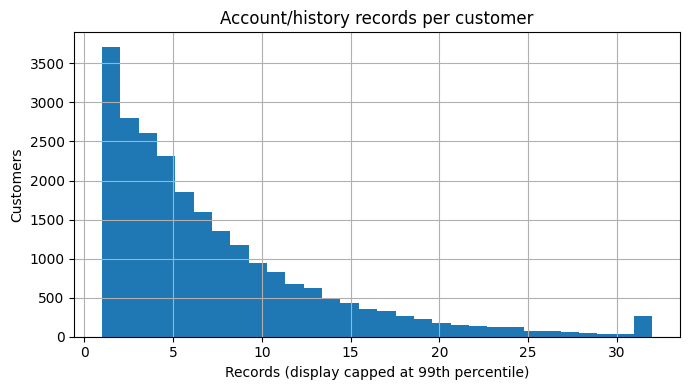

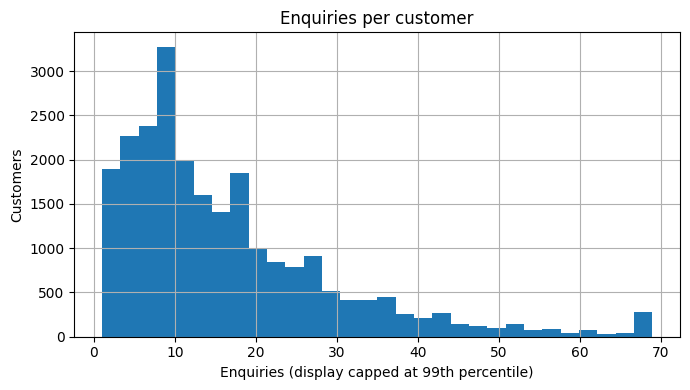

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
acct_per_customer.clip(upper=acct_per_customer.quantile(0.99)).hist(bins=30, ax=ax)
ax.set_title("Account/history records per customer")
ax.set_xlabel("Records (display capped at 99th percentile)")
ax.set_ylabel("Customers")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
enq_per_customer.clip(upper=enq_per_customer.quantile(0.99)).hist(bins=30, ax=ax)
ax.set_title("Enquiries per customer")
ax.set_xlabel("Enquiries (display capped at 99th percentile)")
ax.set_ylabel("Customers")
plt.tight_layout()
plt.show()

## 6. Enhanced payment-history engineering

The project brief highlights payment-history behavior and specifically references a 0–29 DPD feature.

Payment-history strings contain monthly 3-character status blocks. The parser treats:

- `STD` as 0 DPD;
- numeric blocks such as `030`, `060`, `090` as numeric DPD;
- unknown non-numeric codes such as `XXX` as missing.

The earlier model summarized payment history mainly with mean/max DPD. This version also creates explicit delinquency buckets:

- 0–29 DPD
- 30–59 DPD
- 60–89 DPD
- 90+ DPD

It additionally creates an account-level indicator for whether the entire available history stayed in the 0–29 bucket, then averages that indicator across a customer's accounts. This is deliberately aligned with the wording of the benchmark's `payment_history_avg_dpd_0_29_bucket` feature.

In [14]:
def parse_payment_history(value):
    if pd.isna(value):
        return np.array([], dtype=np.float32)

    s = str(value).replace('"', "").replace("'", "").replace(" ", "").upper()
    chunks = re.findall(r".{3}", s)

    vals = []
    for token in chunks:
        if token == "STD":
            vals.append(0.0)
        elif token.isdigit():
            vals.append(float(token))
        else:
            vals.append(np.nan)

    return np.asarray(vals, dtype=np.float32)

def payment_features(value):
    arr = parse_payment_history(value)
    valid = arr[~np.isnan(arr)]

    if valid.size == 0:
        return (
            np.nan, np.nan,
            np.nan, np.nan, np.nan, np.nan,
            np.nan, np.nan, 0
        )

    pos_30 = np.flatnonzero(valid >= 30)
    first_30 = float(pos_30[0] + 1) if pos_30.size else np.nan

    share_0_29 = np.mean((valid >= 0) & (valid <= 29))
    share_30_59 = np.mean((valid >= 30) & (valid <= 59))
    share_60_89 = np.mean((valid >= 60) & (valid <= 89))
    share_90_plus = np.mean(valid >= 90)
    all_0_29 = float(np.all((valid >= 0) & (valid <= 29)))

    return (
        float(np.mean(valid)),
        float(np.max(valid)),
        float(share_0_29),
        float(share_30_59),
        float(share_60_89),
        float(share_90_plus),
        all_0_29,
        first_30,
        int(valid.size)
    )

ph_combined = (
    acct["paymenthistory1"].fillna("").astype(str)
    + acct["paymenthistory2"].fillna("").astype(str)
)

ph_array = np.asarray(
    [payment_features(v) for v in ph_combined],
    dtype=np.float32
)

acct["ph_mean_dpd"] = ph_array[:, 0]
acct["ph_max_dpd"] = ph_array[:, 1]
acct["ph_share_0_29"] = ph_array[:, 2]
acct["ph_share_30_59"] = ph_array[:, 3]
acct["ph_share_60_89"] = ph_array[:, 4]
acct["ph_share_90_plus"] = ph_array[:, 5]
acct["ph_all_0_29"] = ph_array[:, 6]
acct["ph_months_to_first_30_plus"] = ph_array[:, 7]
acct["ph_history_length"] = ph_array[:, 8]

del ph_combined, ph_array
gc.collect()

acct[[
    "ph_mean_dpd", "ph_max_dpd", "ph_share_0_29",
    "ph_share_30_59", "ph_share_60_89", "ph_share_90_plus",
    "ph_all_0_29", "ph_months_to_first_30_plus",
    "ph_history_length"
]].describe()

,ph_mean_dpd,ph_max_dpd,ph_share_0_29,ph_share_30_59,ph_share_60_89,ph_share_90_plus,ph_all_0_29,ph_months_to_first_30_plus,ph_history_length
count,"177,176.0000","177,176.0000","177,176.0000","177,176.0000","177,176.0000","177,176.0000","177,176.0000","10,876.0000","183,928.0000"
mean,5.0999,12.2014,0.9799,0.0051,0.0028,0.0122,0.9386,7.3134,15.4202
std,47.7518,74.7534,0.1083,0.0338,0.0234,0.0882,0.2402,8.8907,12.4353
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
25%,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,2.0000,4.0000
50%,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,3.0000,12.0000
75%,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,10.0000,27.0000
max,900.0000,900.0000,1.0000,1.0000,1.0000,1.0000,1.0000,36.0000,36.0000


## 7. Customer-level Account features

In [15]:
acct_numeric_cols = [
    "high_credit_amt", "cur_balance_amt", "amt_past_due",
    "creditlimit", "cashlimit", "rateofinterest",
    "paymentfrequency", "actualpaymentamount"
]

for c in acct_numeric_cols:
    if c in acct.columns:
        acct[c] = pd.to_numeric(acct[c], errors="coerce")

acct["diff_lastpaymt_opened_dt"] = (acct["last_paymt_dt"] - acct["opened_dt"]).dt.days
acct["account_age_days"] = (acct["dt_opened"] - acct["opened_dt"]).dt.days
acct["is_past_due"] = (acct["amt_past_due"].fillna(0) > 0).astype("int8")
acct["has_30_plus_history"] = (acct["ph_max_dpd"].fillna(-1) >= 30).astype("int8")
acct["is_open_account"] = acct["closed_dt"].isna().astype("int8")

acct_agg = acct.groupby("customer_no", sort=False).agg(
    account_record_count=("customer_no", "size"),
    account_type_nunique=("acct_type", "nunique"),
    owner_type_nunique=("owner_indic", "nunique"),
    open_account_count=("is_open_account", "sum"),

    total_high_credit_amt=("high_credit_amt", "sum"),
    mean_high_credit_amt=("high_credit_amt", "mean"),
    total_cur_balance_amt=("cur_balance_amt", "sum"),
    mean_cur_balance_amt=("cur_balance_amt", "mean"),
    max_cur_balance_amt=("cur_balance_amt", "max"),
    total_amt_past_due=("amt_past_due", "sum"),
    max_amt_past_due=("amt_past_due", "max"),
    past_due_account_count=("is_past_due", "sum"),

    total_creditlimit=("creditlimit", "sum"),
    mean_creditlimit=("creditlimit", "mean"),
    total_cashlimit=("cashlimit", "sum"),
    mean_cashlimit=("cashlimit", "mean"),
    mean_rateofinterest=("rateofinterest", "mean"),
    mean_actualpaymentamount=("actualpaymentamount", "mean"),

    total_diff_lastpaymt_opened_dt=("diff_lastpaymt_opened_dt", "sum"),
    mean_diff_lastpaymt_opened_dt=("diff_lastpaymt_opened_dt", "mean"),
    mean_account_age_days=("account_age_days", "mean"),
    max_account_age_days=("account_age_days", "max"),

    # Benchmark-aligned payment-history features
    payment_history_avg_dpd_0_29_bucket=("ph_all_0_29", "mean"),
    payment_history_share_0_29=("ph_share_0_29", "mean"),
    payment_history_share_30_59=("ph_share_30_59", "mean"),
    payment_history_share_60_89=("ph_share_60_89", "mean"),
    payment_history_share_90_plus=("ph_share_90_plus", "mean"),
    payment_history_mean_dpd=("ph_mean_dpd", "mean"),
    payment_history_max_dpd=("ph_max_dpd", "max"),
    accounts_with_30_plus=("has_30_plus_history", "sum"),
    min_months_last_30_plus=("ph_months_to_first_30_plus", "min"),
    payment_history_mean_length=("ph_history_length", "mean"),
).reset_index()

def safe_divide(num, den):
    return num / den.replace(0, np.nan)

acct_agg["Ratio_currbalance_creditlimit"] = safe_divide(
    acct_agg["total_cur_balance_amt"],
    acct_agg["total_creditlimit"]
)

mean_util_den = acct_agg["mean_creditlimit"].fillna(0) + acct_agg["mean_cashlimit"].fillna(0)
mean_util = safe_divide(acct_agg["mean_cur_balance_amt"], mean_util_den)

acct_agg["utilisation_trend"] = safe_divide(
    acct_agg["Ratio_currbalance_creditlimit"],
    mean_util
)

acct_agg["past_due_account_ratio"] = safe_divide(
    acct_agg["past_due_account_count"].astype(float),
    acct_agg["account_record_count"].astype(float)
)

acct_agg["accounts_30_plus_ratio"] = safe_divide(
    acct_agg["accounts_with_30_plus"].astype(float),
    acct_agg["account_record_count"].astype(float)
)

acct_agg.replace([np.inf, -np.inf], np.nan, inplace=True)
acct_agg.head()

,customer_no,account_record_count,account_type_nunique,owner_type_nunique,open_account_count,total_high_credit_amt,mean_high_credit_amt,total_cur_balance_amt,mean_cur_balance_amt,max_cur_balance_amt,total_amt_past_due,max_amt_past_due,past_due_account_count,total_creditlimit,mean_creditlimit,total_cashlimit,mean_cashlimit,mean_rateofinterest,mean_actualpaymentamount,total_diff_lastpaymt_opened_dt,mean_diff_lastpaymt_opened_dt,mean_account_age_days,max_account_age_days,payment_history_avg_dpd_0_29_bucket,payment_history_share_0_29,payment_history_share_30_59,payment_history_share_60_89,payment_history_share_90_plus,payment_history_mean_dpd,payment_history_max_dpd,accounts_with_30_plus,min_months_last_30_plus,payment_history_mean_length,Ratio_currbalance_creditlimit,utilisation_trend,past_due_account_ratio,accounts_30_plus_ratio
0,12265,3,2,1,2,"78,129.0000","26,043.0000",44810,"14,936.6667",34420,0.0000,NaN,0,"14,000.0000","14,000.0000","1,400.0000","1,400.0000",NaN,"5,603.0000","2,842.0000",947.3333,"1,158.6667","1,328.0000",1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,NaN,25.3333,3.2007,3.3000,0.0000,0.0000
1,15606,14,4,1,7,"854,327.0000","65,717.4615",192116,"13,722.5714",128407,0.0000,NaN,0,"164,000.0000","82,000.0000",0.0000,NaN,39.0000,"6,516.0000","9,642.0000",803.5000,"1,830.9286","3,526.0000",0.7500,0.8884,0.0100,0.0139,0.0877,47.6221,900.0000,3,1.0000,13.2143,1.1714,7.0000,0.0000,0.2143
2,11742,5,5,1,4,"213,590.0000","53,397.5000",165128,"33,025.6000",149000,0.0000,NaN,0,0.0000,NaN,0.0000,NaN,NaN,NaN,670.0000,335.0000,324.4000,"1,220.0000",1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,NaN,5.6000,NaN,NaN,0.0000,0.0000
3,12379,54,6,1,16,"6,478,368.0000","140,834.0870",1522242,"28,189.6667",540985,0.0000,NaN,0,"2,307,500.0000","230,750.0000","466,052.0000","93,210.4000",30.6343,"23,873.6667","48,595.0000","1,033.9362","3,137.8333","5,403.0000",1.0000,1.0000,0.0000,0.0000,0.0000,0.0553,12.0000,0,NaN,13.7407,0.6597,7.5813,0.0000,0.0000
4,17744,4,2,1,4,"169,486.0000","42,371.5000",89114,"22,278.5000",72570,0.0000,NaN,0,"189,000.0000","94,500.0000","34,800.0000","34,800.0000",39.0000,905.0000,"2,632.0000",658.0000,736.5000,"1,256.0000",1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,NaN,19.5000,0.4715,2.7365,0.0000,0.0000


## 8. Customer-level Enquiry features

The brief explicitly suggests enquiry counts in the previous 90 and 365 days, the average gap between `dt_opened` and `enquiry_dt`, and the most frequent enquiry purpose.

A secured/unsecured enquiry-purpose ratio is **not** created because the supplied brief does not provide the code mapping required to classify `enq_purpose` values reliably.

In [16]:
enq["enq_amt"] = pd.to_numeric(enq["enq_amt"], errors="coerce")
enq["days_open_to_enquiry"] = (enq["dt_opened"] - enq["enquiry_dt"]).dt.days

enq["in_30_days"] = enq["days_open_to_enquiry"].between(0, 30, inclusive="both").astype("int8")
enq["in_90_days"] = enq["days_open_to_enquiry"].between(0, 90, inclusive="both").astype("int8")
enq["in_180_days"] = enq["days_open_to_enquiry"].between(0, 180, inclusive="both").astype("int8")
enq["in_365_days"] = enq["days_open_to_enquiry"].between(0, 365, inclusive="both").astype("int8")

def mode_or_nan(s):
    m = s.mode(dropna=True)
    return m.iloc[0] if not m.empty else np.nan

enq_agg = enq.groupby("customer_no", sort=False).agg(
    enquiry_count=("customer_no", "size"),
    enquiry_purpose_nunique=("enq_purpose", "nunique"),
    total_enquiry_amt=("enq_amt", "sum"),
    mean_enquiry_amt=("enq_amt", "mean"),
    max_enquiry_amt=("enq_amt", "max"),
    count_enquiry_recency_30=("in_30_days", "sum"),
    count_enquiry_recency_90=("in_90_days", "sum"),
    count_enquiry_recency_180=("in_180_days", "sum"),
    count_enquiry_recency_365=("in_365_days", "sum"),
    mean_diff_open_enquiry_dt=("days_open_to_enquiry", "mean"),
    min_diff_open_enquiry_dt=("days_open_to_enquiry", "min"),
    max_diff_open_enquiry_dt=("days_open_to_enquiry", "max"),
    max_freq_enquiry=("enq_purpose", mode_or_nan),
).reset_index()

enq_agg.head()

,customer_no,enquiry_count,enquiry_purpose_nunique,total_enquiry_amt,mean_enquiry_amt,max_enquiry_amt,count_enquiry_recency_30,count_enquiry_recency_90,count_enquiry_recency_180,count_enquiry_recency_365,mean_diff_open_enquiry_dt,min_diff_open_enquiry_dt,max_diff_open_enquiry_dt,max_freq_enquiry
0,1,18,4,"4,981,150.0000","276,730.5556","3,500,000.0000",0,0,1,1,"1,443.5000",120.0000,"2,517.0000",10.0000
1,2,67,9,"6,676,632,006.0000","99,651,223.9701","750,000,000.0000",0,2,6,19,778.9403,69.0000,"3,063.0000",51.0000
2,3,1,1,"3,400,000.0000","3,400,000.0000","3,400,000.0000",0,0,0,0,438.0000,438.0000,438.0000,1.0000
3,4,33,5,"49,810,000.0000","1,509,393.9394","4,000,000.0000",0,0,0,0,"1,903.3030",418.0000,"2,842.0000",5.0000
4,5,2,1,"2,000.0000","1,000.0000","1,000.0000",0,0,0,0,"1,497.5000","1,134.0000","1,861.0000",10.0000


## 9. Demographic feature preparation

The 79 demographic variables are anonymized. This notebook therefore uses generic, reproducible rules instead of assigning undocumented meanings:

- retain numeric anonymized features;
- convert strongly date-like anonymized text variables into elapsed-day features relative to `dt_opened`;
- keep low/moderate-cardinality categoricals;
- remove high-cardinality text variables that could behave like identifiers.

In [17]:
demo_model = demo.copy()

feature_cols = [c for c in demo_model.columns if c.startswith("feature_")]
reference_date = demo_model["dt_opened"]

derived_date_cols = []
categorical_candidates = []

for c in feature_cols:
    if pd.api.types.is_numeric_dtype(demo_model[c]):
        continue

    raw = demo_model[c].replace(["0000-00-00", "", " "], np.nan)
    parsed = pd.to_datetime(raw, errors="coerce", dayfirst=True)

    non_missing = raw.notna().sum()
    parse_rate = parsed.notna().sum() / non_missing if non_missing else 0

    if parse_rate >= 0.80 and parsed.notna().sum() >= 50:
        new_col = f"{c}_days_from_reference"
        demo_model[new_col] = (reference_date - parsed).dt.days
        derived_date_cols.append(new_col)
    else:
        categorical_candidates.append(c)

numeric_demo_features = [
    c for c in feature_cols
    if pd.api.types.is_numeric_dtype(demo_model[c])
] + derived_date_cols

kept_categoricals = []
dropped_high_cardinality = []

n_demo = len(demo_model)

for c in categorical_candidates:
    nunique = demo_model[c].nunique(dropna=True)
    if nunique <= min(500, max(20, int(0.10 * n_demo))):
        kept_categoricals.append(c)
    else:
        dropped_high_cardinality.append(c)

demo_keep = (
    ["customer_no", "Bad_label", "dt_opened"]
    + numeric_demo_features
    + kept_categoricals
)

demo_features = demo_model[demo_keep].copy()

print("Numeric demographic features:", len(numeric_demo_features))
print("Categorical demographic features retained:", len(kept_categoricals))
print("High-cardinality text features excluded:", len(dropped_high_cardinality))

Numeric demographic features: 37
Categorical demographic features retained: 34
High-cardinality text features excluded: 8


## 10. Build the one-row-per-customer feature matrix

In [18]:
feature_matrix = (
    demo_features
    .merge(acct_agg, on="customer_no", how="left", validate="one_to_one")
    .merge(enq_agg, on="customer_no", how="left", validate="one_to_one")
)

feature_matrix["has_account_history"] = feature_matrix["account_record_count"].notna().astype("int8")
feature_matrix["has_enquiry_history"] = feature_matrix["enquiry_count"].notna().astype("int8")

print("Feature matrix shape:", feature_matrix.shape)
print("Customers:", feature_matrix["customer_no"].nunique())
print("Target missing:", feature_matrix["Bad_label"].isna().sum())

feature_matrix.head()

Feature matrix shape: (23896, 125)
Customers: 23896
Target missing: 0


,customer_no,Bad_label,dt_opened,feature_3,feature_4,feature_6,feature_7,feature_14,feature_19,feature_25,feature_26,feature_29,feature_30,feature_31,feature_34,feature_35,feature_39,feature_40,feature_41,feature_42,feature_44,feature_49,feature_52,feature_55,feature_56,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_71,feature_74,feature_76,feature_78,feature_2_days_from_reference,feature_21_days_from_reference,feature_53_days_from_reference,feature_54_days_from_reference,feature_75_days_from_reference,feature_1,feature_5,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_15,feature_17,feature_18,feature_23,feature_27,feature_28,feature_32,feature_33,feature_36,feature_37,feature_43,feature_46,feature_48,feature_50,feature_51,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_70,feature_72,feature_73,feature_79,account_record_count,account_type_nunique,owner_type_nunique,open_account_count,total_high_credit_amt,mean_high_credit_amt,total_cur_balance_amt,mean_cur_balance_amt,max_cur_balance_amt,total_amt_past_due,max_amt_past_due,past_due_account_count,total_creditlimit,mean_creditlimit,total_cashlimit,mean_cashlimit,mean_rateofinterest,mean_actualpaymentamount,total_diff_lastpaymt_opened_dt,mean_diff_lastpaymt_opened_dt,mean_account_age_days,max_account_age_days,payment_history_avg_dpd_0_29_bucket,payment_history_share_0_29,payment_history_share_30_59,payment_history_share_60_89,payment_history_share_90_plus,payment_history_mean_dpd,payment_history_max_dpd,accounts_with_30_plus,min_months_last_30_plus,payment_history_mean_length,Ratio_currbalance_creditlimit,utilisation_trend,past_due_account_ratio,accounts_30_plus_ratio,enquiry_count,enquiry_purpose_nunique,total_enquiry_amt,mean_enquiry_amt,max_enquiry_amt,count_enquiry_recency_30,count_enquiry_recency_90,count_enquiry_recency_180,count_enquiry_recency_365,mean_diff_open_enquiry_dt,min_diff_open_enquiry_dt,max_diff_open_enquiry_dt,max_freq_enquiry,has_account_history,has_enquiry_history
0,1,0,2015-04-18,650.0000,2.0000,14.0000,"500,000.0000",0.0000,1.0000,1.0000,2.0000,"400,610.0000","1,965.0000",0.0000,2.0000,"90,000.0000",0.0000,0.0000,0.0000,0.0000,"400,059.0000",NaN,0.0000,1.0000,21.0000,21.0000,15.0000,"400,610.0000",0.0000,2.0000,"90,000.0000",21.0000,NaN,0.0000,1.0000,5.0000,"-18,401.0000",686.0000,-426.0000,NaN,Insignia,Card Setup,NaN,NaN,NaN,Y,IS1,NaN,159,4284,NaN,N,NaN,Mumbai / Navi Mumbai / Thane,Self,Y,NaN,NaN,Mumbai,PAN Card,The Ratnakar Bank Ltd.,Y,State Bank of India,NaN,Y,Y,N,NaN,Y,1965-0,Nov-00,R,NaN,N,18,4,2,6,"7,900,063.0000","526,670.8667",4714857,"261,936.5000",2528846,"2,538,209.0000","2,528,846.0000",2,"670,000.0000","335,000.0000","168,000.0000","168,000.0000",17.7108,"35,543.0000","14,960.0000","1,496.0000","4,421.5882","6,876.0000",0.9167,0.9167,0.0000,0.0000,0.0833,15.0833,181.0000,1,1.0000,11.0000,7.0371,13.5134,0.1111,0.0556,18,4,"4,981,150.0000","276,730.5556","3,500,000.0000",0,0,1,1,"1,443.5000",120.0000,"2,517.0000",10.0000,1,1
1,2,0,2015-04-21,760.0000,1.0000,14.0000,"1,200,000.0000",0.0000,1.0000,1.0000,2.0000,"560,042.0000","1,969.0000",0.0000,2.0000,1.0000,0.0000,0.0000,0.0000,0.0000,"560,042.0000",NaN,0.0000,1.0000,17.0000,17.0000,12.0000,"560,042.0000",0.0000,2.0000,1.0000,17.0000,NaN,0.0000,1.0000,0.0000,"-17,251.0000",NaN,-423.0000,NaN,Insignia,Card Setup,NaN,NaN,NaN,Y,IS1,NaN,91,4077,NaN,N,NaN,Bengaluru,Self,Y,NaN,NaN,Bangalore,PAN Card,The Ratnakar Bank Ltd.,N,NaN,NaN,Y,Y,N,NaN,Y,1969-0,Nov-00,R,NaN,N,2,1,1,2,"1,117,595.0000","558,797.5000",30754,"15,377.0000",24007,0.0000,NaN,0,"1,000,000.0000","1,000,000.0000",1.0000,1.0000,NaN,NaN,"4,070.0000","2,035.0000","2,083.0000","2,086.0000",1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,NaN,35.0000,0.0308,2.0000,0.0000,0.0000,67,9,"6,676,632,006.0000","99,651,223.9701","750,000,000.0000",0,2,6,19,778.9403,69.0000,"3,063.0000",51.0000,1,1
2,3,0,2015-04-22,774.0000,1.0000,14.0000,"700,000.0000",0.0000,2.00

In [19]:
feature_summary = pd.DataFrame({
    "feature": [
        c for c in feature_matrix.columns
        if c not in ["customer_no", "Bad_label", "dt_opened"]
    ],
    "dtype": [
        str(feature_matrix[c].dtype)
        for c in feature_matrix.columns
        if c not in ["customer_no", "Bad_label", "dt_opened"]
    ],
    "missing_pct": [
        100 * feature_matrix[c].isna().mean()
        for c in feature_matrix.columns
        if c not in ["customer_no", "Bad_label", "dt_opened"]
    ],
    "nunique": [
        feature_matrix[c].nunique(dropna=True)
        for c in feature_matrix.columns
        if c not in ["customer_no", "Bad_label", "dt_opened"]
    ],
}).sort_values("missing_pct", ascending=False)

feature_summary.head(25)

,feature,dtype,missing_pct,nunique
64,feature_61,object,99.9623,8
29,feature_74,float64,99.9289,3
47,feature_18,object,99.9247,12
41,feature_10,object,99.7866,7
36,feature_75_days_from_reference,float64,99.7447,61
18,feature_49,float64,99.5648,18
81,max_amt_past_due,float64,96.7107,579
46,feature_17,object,95.7022,302
40,feature_9,object,94.7230,19
39,feature_8,object,94.7230,19


## 11. Development / holdout split and preprocessing

The initial benchmark comparison uses a stratified random holdout so it is directly comparable across models.

A separate **out-of-time** assessment is performed later using the reference-date ordering.

In [20]:
X = feature_matrix.drop(columns=["customer_no", "Bad_label", "dt_opened"])
y = feature_matrix["Bad_label"].astype(int)
reference_dates = feature_matrix["dt_opened"].copy()

constant_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
if constant_cols:
    X = X.drop(columns=constant_cols)

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, reference_dates,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1,
        encoded_missing_value=-1
    )),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

print("Training customers:", len(X_train))
print("Test customers    :", len(X_test))
print("Bad rate train    :", round(y_train.mean(), 4))
print("Bad rate test     :", round(y_test.mean(), 4))

Training customers: 19116
Test customers    : 4780
Bad rate train    : 0.042
Bad rate test     : 0.0421


## 12. Credit-risk metrics

The notebook reports:

- ROC-AUC
- **Gini = 2 × AUC − 1**
- **KS (Kolmogorov–Smirnov)** between cumulative bad and good distributions
- Average Precision

KS is calculated directly from ranked model scores rather than approximated only from deciles.

In [21]:
def gini_from_auc(auc):
    return 2 * auc - 1

def ks_statistic(y_true, y_prob):
    d = pd.DataFrame({
        "y": np.asarray(y_true),
        "p": np.asarray(y_prob),
    }).sort_values("p", ascending=False)

    bad_total = d["y"].sum()
    good_total = len(d) - bad_total

    if bad_total == 0 or good_total == 0:
        return np.nan

    cum_bad = d["y"].cumsum() / bad_total
    cum_good = (1 - d["y"]).cumsum() / good_total
    return float(np.max(np.abs(cum_bad - cum_good)))

def evaluate_probabilities(name, y_true, y_prob):
    auc = roc_auc_score(y_true, y_prob)
    return {
        "model": name,
        "ROC_AUC": auc,
        "Gini": gini_from_auc(auc),
        "KS": ks_statistic(y_true, y_prob),
        "Average_Precision": average_precision_score(y_true, y_prob),
    }

## 13. Conventional model comparison

Logistic Regression remains an interpretable raw-feature baseline. Random Forest and Extra Trees provide nonlinear ensemble references.

In [22]:
models = {
    "Raw Logistic Regression": LogisticRegression(
        max_iter=1500,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=180,
        max_depth=14,
        min_samples_leaf=8,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=180,
        max_depth=16,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    ),
}

cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_rows = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", clone(preprocessor)),
        ("model", clone(model)),
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring={"auc": "roc_auc", "ap": "average_precision"},
        n_jobs=1,
        return_train_score=False,
    )

    mean_auc = scores["test_auc"].mean()

    cv_rows.append({
        "model": name,
        "CV_ROC_AUC_mean": mean_auc,
        "CV_Gini_mean": gini_from_auc(mean_auc),
        "CV_ROC_AUC_std": scores["test_auc"].std(),
        "CV_Average_Precision_mean": scores["test_ap"].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("CV_Gini_mean", ascending=False)
cv_results

,model,CV_ROC_AUC_mean,CV_Gini_mean,CV_ROC_AUC_std,CV_Average_Precision_mean
1,Random Forest,0.6617,0.3235,0.0122,0.0776
0,Raw Logistic Regression,0.6426,0.2852,0.0082,0.0692
2,Extra Trees,0.6266,0.2532,0.0109,0.0660


## 14. WOE / IV credit scorecard reference model

A traditional credit-risk scorecard workflow often uses **Weight of Evidence (WOE)** and **Information Value (IV)** because they provide a transparent view of how feature bins relate to bad rate.

This implementation is intentionally leakage-aware:

- bins are created on the training sample only;
- WOE values are estimated on the training sample only;
- the holdout set is transformed using those fitted mappings;
- numeric features try progressively coarser quantile binning until the binned bad-rate relationship is reasonably monotonic, where possible.

WOE/IV is presented here as an interpretable **reference scorecard model**, not as a claim that one modeling method is universally required.

In [23]:
def _safe_spearman(x, y):
    if len(x) < 2:
        return 1.0
    xr = pd.Series(x).rank(method="average")
    yr = pd.Series(y).rank(method="average")
    if xr.nunique() <= 1 or yr.nunique() <= 1:
        return 1.0
    return float(np.corrcoef(xr, yr)[0, 1])

class WOETransformer:
    def __init__(self, max_bins=10, min_bins=3, monotonic_threshold=0.80, smoothing=0.5):
        self.max_bins = max_bins
        self.min_bins = min_bins
        self.monotonic_threshold = monotonic_threshold
        self.smoothing = smoothing
        self.specs_ = {}
        self.iv_table_ = None

    def _woe_table(self, bins, y):
        temp = pd.DataFrame({"bin": bins, "y": np.asarray(y)})
        grouped = temp.groupby("bin", dropna=False, observed=False)["y"].agg(["count", "sum"])
        grouped = grouped.rename(columns={"sum": "bad"})
        grouped["good"] = grouped["count"] - grouped["bad"]

        n_bins = len(grouped)
        total_bad = grouped["bad"].sum()
        total_good = grouped["good"].sum()

        grouped["dist_bad"] = (
            grouped["bad"] + self.smoothing
        ) / (total_bad + self.smoothing * n_bins)

        grouped["dist_good"] = (
            grouped["good"] + self.smoothing
        ) / (total_good + self.smoothing * n_bins)

        grouped["woe"] = np.log(grouped["dist_bad"] / grouped["dist_good"])
        grouped["iv_component"] = (
            grouped["dist_bad"] - grouped["dist_good"]
        ) * grouped["woe"]

        return grouped

    def _fit_numeric(self, s, y):
        numeric = pd.to_numeric(s, errors="coerce")

        best_edges = None
        best_table = None
        best_abs_rho = -np.inf

        for q in range(self.max_bins, self.min_bins - 1, -1):
            non_missing = numeric.dropna()

            if non_missing.nunique() < 2:
                break

            try:
                _, raw_edges = pd.qcut(
                    non_missing,
                    q=min(q, non_missing.nunique()),
                    retbins=True,
                    duplicates="drop"
                )
            except ValueError:
                continue

            raw_edges = np.unique(raw_edges)

            if len(raw_edges) < 3:
                continue

            edges = raw_edges.astype(float).copy()
            edges[0] = -np.inf
            edges[-1] = np.inf

            binned = pd.cut(numeric, bins=edges, include_lowest=True)
            labels = binned.astype("object")
            labels = labels.where(pd.notna(labels), "__MISSING__")

            tab = self._woe_table(labels, y)

            non_missing_tab = tab.loc[
                [idx for idx in tab.index if idx != "__MISSING__"]
            ].copy()

            if len(non_missing_tab) >= 2:
                bad_rate = non_missing_tab["bad"] / non_missing_tab["count"]
                rho = _safe_spearman(range(len(bad_rate)), bad_rate.values)
                abs_rho = abs(rho)
            else:
                abs_rho = 1.0

            if abs_rho > best_abs_rho:
                best_abs_rho = abs_rho
                best_edges = edges
                best_table = tab

            if abs_rho >= self.monotonic_threshold:
                break

        if best_edges is None:
            labels = numeric.astype("object")
            labels = labels.where(pd.notna(labels), "__MISSING__")
            best_table = self._woe_table(labels, y)
            best_edges = None

        return best_edges, best_table, best_abs_rho

    def _fit_categorical(self, s, y):
        cat = s.astype("object")
        cat = cat.where(pd.notna(cat), "__MISSING__").astype(str)

        # Pool very rare levels for stability.
        freq = cat.value_counts(normalize=True)
        rare = set(freq[freq < 0.005].index)
        if rare:
            cat = cat.where(~cat.isin(rare), "__RARE__")

        tab = self._woe_table(cat, y)
        return rare, tab

    def fit(self, X, y):
        self.specs_ = {}
        iv_rows = []

        for col in X.columns:
            s = X[col]

            if pd.api.types.is_numeric_dtype(s):
                edges, tab, monotonicity = self._fit_numeric(s, y)
                mapping = tab["woe"].to_dict()

                self.specs_[col] = {
                    "type": "numeric",
                    "edges": edges,
                    "mapping": mapping,
                }

                iv_rows.append({
                    "feature": col,
                    "IV": float(tab["iv_component"].sum()),
                    "type": "numeric",
                    "monotonicity_abs_spearman": monotonicity,
                    "bins": len(tab),
                })

            else:
                rare, tab = self._fit_categorical(s, y)
                mapping = tab["woe"].to_dict()

                self.specs_[col] = {
                    "type": "categorical",
                    "rare": rare,
                    "mapping": mapping,
                }

                iv_rows.append({
                    "feature": col,
                    "IV": float(tab["iv_component"].sum()),
                    "type": "categorical",
                    "monotonicity_abs_spearman": np.nan,
                    "bins": len(tab),
                })

        self.iv_table_ = (
            pd.DataFrame(iv_rows)
            .sort_values("IV", ascending=False)
            .reset_index(drop=True)
        )
        return self

    def transform(self, X):
        out = pd.DataFrame(index=X.index)

        for col, spec in self.specs_.items():
            s = X[col]

            if spec["type"] == "numeric":
                numeric = pd.to_numeric(s, errors="coerce")
                edges = spec["edges"]

                if edges is None:
                    labels = numeric.astype("object")
                else:
                    labels = pd.cut(numeric, bins=edges, include_lowest=True).astype("object")

                labels = labels.where(pd.notna(labels), "__MISSING__")
                out[col] = labels.map(spec["mapping"]).fillna(0.0).astype(float)

            else:
                cat = s.astype("object")
                cat = cat.where(pd.notna(cat), "__MISSING__").astype(str)

                if spec["rare"]:
                    cat = cat.where(~cat.isin(spec["rare"]), "__RARE__")

                out[col] = cat.map(spec["mapping"]).fillna(0.0).astype(float)

        return out

    def fit_transform(self, X, y):
        return self.fit(X, y).transform(X)

In [24]:
woe = WOETransformer(
    max_bins=10,
    min_bins=3,
    monotonic_threshold=0.80,
    smoothing=0.5
)

X_train_woe_all = woe.fit_transform(X_train, y_train)
X_test_woe_all = woe.transform(X_test)

iv_table = woe.iv_table_.copy()

# Conventional screening guidance is used only as a practical filter:
# retain features with non-trivial IV, while excluding extremely high IV
# values that deserve leakage/instability investigation.
selected_woe_features = (
    iv_table.loc[(iv_table["IV"] >= 0.01) & (iv_table["IV"] <= 1.0), "feature"]
    .head(25)
    .tolist()
)

if len(selected_woe_features) < 5:
    selected_woe_features = iv_table.head(15)["feature"].tolist()

print("Selected WOE features:", len(selected_woe_features))
iv_table.head(30)

Selected WOE features: 25


,feature,IV,type,monotonicity_abs_spearman,bins
0,total_amt_past_due,0.5149,numeric,-inf,480
1,feature_7,0.1408,numeric,1.0000,11
2,total_creditlimit,0.1359,numeric,0.9500,9
3,total_cashlimit,0.1297,numeric,0.9524,8
4,count_enquiry_recency_180,0.1097,numeric,1.0000,6
5,feature_52,0.1039,numeric,0.9429,7
6,count_enquiry_recency_90,0.1039,numeric,1.0000,4
7,count_enquiry_recency_365,0.0993,numeric,0.9524,8
8,total_diff_lastpaymt_opened_dt,0.0977,numeric,0.9273,10
9,feature_53_days_from_reference,0.0963,numeric,0.6000,6


In [25]:
woe_logit = LogisticRegression(
    max_iter=2000,
    C=0.5,
    solver="lbfgs",
    random_state=RANDOM_STATE
)

woe_logit.fit(
    X_train_woe_all[selected_woe_features],
    y_train
)

woe_test_prob = woe_logit.predict_proba(
    X_test_woe_all[selected_woe_features]
)[:, 1]

woe_eval = evaluate_probabilities(
    "WOE Logistic Scorecard",
    y_test,
    woe_test_prob
)

pd.DataFrame([woe_eval])

,model,ROC_AUC,Gini,KS,Average_Precision
0,WOE Logistic Scorecard,0.6606,0.3212,0.2624,0.0722


In [26]:
woe_coefficients = pd.DataFrame({
    "feature": selected_woe_features,
    "coefficient": woe_logit.coef_[0],
}).merge(
    iv_table[["feature", "IV", "monotonicity_abs_spearman"]],
    on="feature",
    how="left"
).sort_values("IV", ascending=False)

woe_coefficients.head(25)

,feature,coefficient,IV,monotonicity_abs_spearman
0,total_amt_past_due,0.3860,0.5149,-inf
1,feature_7,0.3965,0.1408,1.0000
2,total_creditlimit,0.1329,0.1359,0.9500
3,total_cashlimit,0.3932,0.1297,0.9524
4,count_enquiry_recency_180,0.2073,0.1097,1.0000
5,feature_52,-0.0174,0.1039,0.9429
6,count_enquiry_recency_90,0.4198,0.1039,1.0000
7,count_enquiry_recency_365,0.3443,0.0993,0.9524
8,total_diff_lastpaymt_opened_dt,0.3144,0.0977,0.9273
9,feature_53_days_from_reference,0.3533,0.0963,0.6000


## 15. Tuned gradient boosting

Gradient boosting is added because nonlinear boosting methods are strong benchmarks for structured/tabular credit-risk data.

The notebook uses **XGBoost when installed**. If it is unavailable, it falls back to scikit-learn's histogram gradient boosting so the workflow remains executable.

The randomized search uses more than the earlier token tuning budget and searches learning rate, depth, sampling and regularization controls. The search objective is ROC-AUC; Gini follows directly from AUC.

In [27]:
try:
    from xgboost import XGBClassifier
    BOOSTING_BACKEND = "XGBoost"

    boosting_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
    )

    boosting_params = {
        "model__n_estimators": [180, 250, 350, 450],
        "model__max_depth": [2, 3, 4, 5],
        "model__learning_rate": [0.02, 0.03, 0.05, 0.08],
        "model__subsample": [0.70, 0.85, 1.00],
        "model__colsample_bytree": [0.70, 0.85, 1.00],
        "model__min_child_weight": [1, 3, 5, 10],
        "model__reg_lambda": [1, 5, 10],
        "model__reg_alpha": [0.0, 0.1, 0.5],
        "model__scale_pos_weight": [1, 5, 10, 20],
    }

except ImportError:
    BOOSTING_BACKEND = "HistGradientBoosting"

    boosting_model = HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        early_stopping=True,
    )

    boosting_params = {
        "model__learning_rate": [0.03, 0.05, 0.08, 0.10],
        "model__max_iter": [150, 220, 300],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__min_samples_leaf": [10, 20, 30, 50],
        "model__l2_regularization": [0.0, 0.5, 1.0, 5.0],
    }

print("Boosting backend:", BOOSTING_BACKEND)

Boosting backend: XGBoost


In [28]:
boosting_pipeline = Pipeline([
    ("preprocess", clone(preprocessor)),
    ("model", boosting_model),
])

boosting_search = RandomizedSearchCV(
    estimator=boosting_pipeline,
    param_distributions=boosting_params,
    n_iter=BOOSTING_SEARCH_ITER,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1,
    refit=True,
)

boosting_search.fit(X_train, y_train)

best_boosting = boosting_search.best_estimator_

print("Best CV ROC-AUC:", round(boosting_search.best_score_, 4))
print("Best CV Gini   :", round(gini_from_auc(boosting_search.best_score_), 4))
print("Best parameters:")
boosting_search.best_params_

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best CV ROC-AUC: 0.6676
Best CV Gini   : 0.3352
Best parameters:


{'model__subsample': 0.7,
 'model__scale_pos_weight': 10,
 'model__reg_lambda': 1,
 'model__reg_alpha': 0.1,
 'model__n_estimators': 180,
 'model__min_child_weight': 5,
 'model__max_depth': 3,
 'model__learning_rate': 0.03,
 'model__colsample_bytree': 0.85}

## 16. Holdout model comparison: benchmark, WOE scorecard and boosting

In [29]:
fitted_holdout_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", clone(preprocessor)),
        ("model", clone(model)),
    ])
    pipe.fit(X_train, y_train)
    fitted_holdout_models[name] = pipe

holdout_rows = []

for name, pipe in fitted_holdout_models.items():
    p = pipe.predict_proba(X_test)[:, 1]
    holdout_rows.append(evaluate_probabilities(name, y_test, p))

holdout_rows.append(woe_eval)

boosting_test_prob = best_boosting.predict_proba(X_test)[:, 1]
holdout_rows.append(
    evaluate_probabilities(
        f"Tuned {BOOSTING_BACKEND}",
        y_test,
        boosting_test_prob
    )
)

holdout_results = (
    pd.DataFrame(holdout_rows)
    .sort_values("Gini", ascending=False)
    .reset_index(drop=True)
)

holdout_results

,model,ROC_AUC,Gini,KS,Average_Precision
0,Tuned XGBoost,0.6843,0.3685,0.2865,0.0821
1,Random Forest,0.6694,0.3388,0.2853,0.0740
2,Extra Trees,0.6642,0.3283,0.2677,0.0725
3,WOE Logistic Scorecard,0.6606,0.3212,0.2624,0.0722
4,Raw Logistic Regression,0.6575,0.3150,0.2677,0.0720


In [30]:
boosting_eval = evaluate_probabilities(
    f"Tuned {BOOSTING_BACKEND}",
    y_test,
    boosting_test_prob
)

benchmark_comparison = pd.DataFrame({
    "metric": ["Test Gini", "Benchmark Gini", "Gap vs benchmark"],
    "value": [
        boosting_eval["Gini"],
        BENCHMARK_GINI,
        boosting_eval["Gini"] - BENCHMARK_GINI,
    ],
})
benchmark_comparison

,metric,value
0,Test Gini,0.3685
1,Benchmark Gini,0.3790
2,Gap vs benchmark,-0.0105


In [31]:
gap = boosting_eval["Gini"] - BENCHMARK_GINI

if gap >= 0:
    print(
        f"The tuned boosting model exceeds the supplied benchmark "
        f"by {gap:.4f} ({100*gap:.2f} percentage points of Gini)."
    )
else:
    print(
        f"The tuned boosting model remains below the supplied benchmark "
        f"by {abs(gap):.4f} ({100*abs(gap):.2f} percentage points of Gini)."
    )
    print(
        "This is reported transparently rather than hidden. "
        "The next investigation should focus on benchmark feature-definition alignment, "
        "additional documented business mappings, and validation of the original benchmark split."
    )

The tuned boosting model remains below the supplied benchmark by 0.0105 (1.05 percentage points of Gini).
This is reported transparently rather than hidden. The next investigation should focus on benchmark feature-definition alignment, additional documented business mappings, and validation of the original benchmark split.


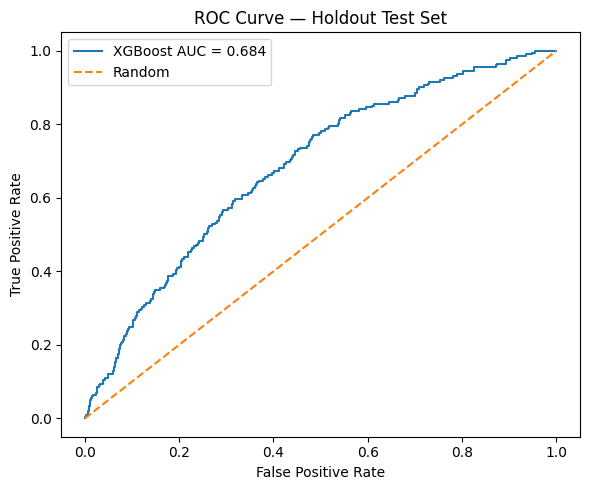

In [32]:
fpr, tpr, _ = roc_curve(y_test, boosting_test_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"{BOOSTING_BACKEND} AUC = {boosting_eval['ROC_AUC']:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Holdout Test Set")
ax.legend()
plt.tight_layout()
plt.show()

## 17. Final-model cross-validation mean ± standard deviation

The final discrimination number should not depend only on one random split. The tuned boosting configuration is therefore re-evaluated using stratified cross-validation on the full modeling sample.

This reports the final model's **CV AUC mean ± standard deviation** and the corresponding mean Gini.

In [33]:
final_cv = StratifiedKFold(
    n_splits=FINAL_CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

final_cv_scores = cross_validate(
    clone(best_boosting),
    X,
    y,
    cv=final_cv,
    scoring={"auc": "roc_auc", "ap": "average_precision"},
    n_jobs=1,
    return_train_score=False,
)

final_cv_auc_mean = final_cv_scores["test_auc"].mean()
final_cv_auc_std = final_cv_scores["test_auc"].std()

final_cv_summary = pd.DataFrame({
    "metric": [
        "CV ROC-AUC mean",
        "CV ROC-AUC std",
        "CV Gini mean",
        "CV Average Precision mean",
    ],
    "value": [
        final_cv_auc_mean,
        final_cv_auc_std,
        gini_from_auc(final_cv_auc_mean),
        final_cv_scores["test_ap"].mean(),
    ],
})
final_cv_summary

,metric,value
0,CV ROC-AUC mean,0.6840
1,CV ROC-AUC std,0.0226
2,CV Gini mean,0.3680
3,CV Average Precision mean,0.0888


## 18. Feature gain / importance

The project brief explicitly asks for a feature matrix with gain.

When XGBoost is available, this section reports **true split gain** from the fitted booster. If the fallback estimator is used, the notebook reports its available feature importance separately and does not mislabel a different quantity as XGBoost gain.

In [34]:
feature_names = best_boosting.named_steps["preprocess"].get_feature_names_out()
model_obj = best_boosting.named_steps["model"]

if BOOSTING_BACKEND == "XGBoost":
    booster = model_obj.get_booster()
    raw_gain = booster.get_score(importance_type="gain")

    # XGBoost may expose f0/f1... positions after a transformed matrix.
    gain_rows = []
    for k, v in raw_gain.items():
        if k.startswith("f") and k[1:].isdigit():
            idx = int(k[1:])
            feature = feature_names[idx] if idx < len(feature_names) else k
        else:
            feature = k
        gain_rows.append((feature, v))

    feature_gain = (
        pd.DataFrame(gain_rows, columns=["feature", "gain"])
        .sort_values("gain", ascending=False)
        .reset_index(drop=True)
    )

    if len(feature_gain):
        feature_gain["gain_share"] = feature_gain["gain"] / feature_gain["gain"].sum()
        feature_gain["cumulative_gain_share"] = feature_gain["gain_share"].cumsum()

else:
    # HistGradientBoosting does not expose native split gain.
    # Use model-agnostic permutation importance on the original holdout features.
    from sklearn.inspection import permutation_importance

    perm = permutation_importance(
        best_boosting,
        X_test,
        y_test,
        scoring="roc_auc",
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=1
    )

    feature_gain = (
        pd.DataFrame({
            "feature": X_test.columns,
            "importance": perm.importances_mean,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

feature_gain.head(30)

,feature,gain,gain_share,cumulative_gain_share
0,count_enquiry_recency_180,146.4315,0.0241,0.0241
1,feature_7,141.8042,0.0234,0.0475
2,payment_history_avg_dpd_0_29_bucket,132.8224,0.0219,0.0694
3,feature_50,126.4481,0.0208,0.0902
4,total_cashlimit,123.7760,0.0204,0.1106
5,count_enquiry_recency_365,105.8386,0.0174,0.1281
6,accounts_30_plus_ratio,105.0909,0.0173,0.1454
7,count_enquiry_recency_90,98.9211,0.0163,0.1617
8,feature_52,98.6363,0.0163,0.1779
9,total_creditlimit,94.1804,0.0155,0.1935


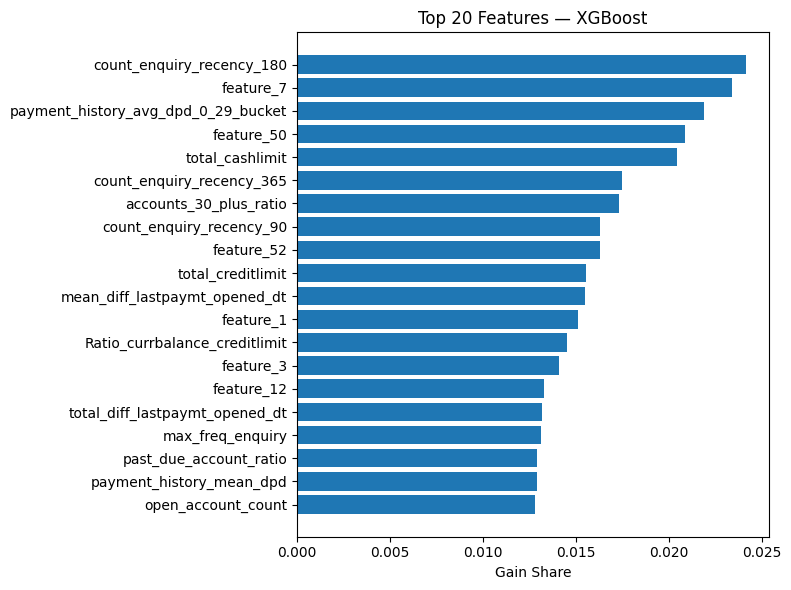

In [35]:
top_n = min(20, len(feature_gain))
metric_col = "gain_share" if "gain_share" in feature_gain.columns else "importance"

fig, ax = plt.subplots(figsize=(8, 6))
plot_df = feature_gain.head(top_n).sort_values(metric_col)
ax.barh(plot_df["feature"], plot_df[metric_col])
ax.set_title(f"Top {top_n} Features — {BOOSTING_BACKEND}")
ax.set_xlabel(metric_col.replace("_", " ").title())
plt.tight_layout()
plt.show()

In [36]:
benchmark_feature_check = [
    "payment_history_avg_dpd_0_29_bucket",
    "min_months_last_30_plus",
    "utilisation_trend",
    "count_enquiry_recency_365",
    "Ratio_currbalance_creditlimit",
    "mean_diff_lastpaymt_opened_dt",
    "mean_diff_open_enquiry_dt",
    "payment_history_mean_length",
    "max_freq_enquiry",
    "count_enquiry_recency_90",
]

present = [f for f in benchmark_feature_check if f in X.columns]

pd.DataFrame({
    "benchmark_suggested_feature": benchmark_feature_check,
    "implemented_in_feature_matrix": [
        f in X.columns for f in benchmark_feature_check
    ],
})

,benchmark_suggested_feature,implemented_in_feature_matrix
0,payment_history_avg_dpd_0_29_bucket,True
1,min_months_last_30_plus,True
2,utilisation_trend,True
3,count_enquiry_recency_365,True
4,Ratio_currbalance_creditlimit,True
5,mean_diff_lastpaymt_opened_dt,True
6,mean_diff_open_enquiry_dt,True
7,payment_history_mean_length,True
8,max_freq_enquiry,True
9,count_enquiry_recency_90,True


## 19. Rank ordering and KS by risk decile

**Decile 10** is the highest predicted-risk group and **Decile 1** is the lowest.

Perfect monotonicity is desirable but not guaranteed in a finite holdout sample. Small adjacent reversals should be reported and investigated rather than manually forced away.

In [37]:
rank_df = pd.DataFrame({
    "actual_bad": y_test.to_numpy(),
    "predicted_probability": boosting_test_prob,
})

rank_df["decile"] = pd.qcut(
    rank_df["predicted_probability"].rank(method="first"),
    q=10,
    labels=list(range(1, 11))
).astype(int)

rank_order = (
    rank_df.groupby("decile", observed=True)
    .agg(
        customers=("actual_bad", "size"),
        bad_customers=("actual_bad", "sum"),
        bad_rate=("actual_bad", "mean"),
        avg_predicted_probability=("predicted_probability", "mean"),
        min_score=("predicted_probability", "min"),
        max_score=("predicted_probability", "max"),
    )
    .reset_index()
)

rank_order["good_customers"] = rank_order["customers"] - rank_order["bad_customers"]

# Compute cumulative distributions from highest risk to lowest.
risk_order = rank_order.sort_values("decile", ascending=False).copy()
risk_order["cum_bad_pct"] = risk_order["bad_customers"].cumsum() / risk_order["bad_customers"].sum()
risk_order["cum_good_pct"] = risk_order["good_customers"].cumsum() / risk_order["good_customers"].sum()
risk_order["decile_KS"] = np.abs(risk_order["cum_bad_pct"] - risk_order["cum_good_pct"])
risk_order["bad_rate_pct"] = 100 * risk_order["bad_rate"]

risk_order

,decile,customers,bad_customers,bad_rate,avg_predicted_probability,min_score,max_score,good_customers,cum_bad_pct,cum_good_pct,decile_KS,bad_rate_pct
9,10,478,49,0.1025,0.4944,0.4308,0.6723,429,0.2438,0.0937,0.1501,10.2510
8,9,478,30,0.0628,0.3932,0.3639,0.4306,448,0.3930,0.1915,0.2015,6.2762
7,8,478,32,0.0669,0.3386,0.3160,0.3638,446,0.5522,0.2889,0.2633,6.6946
6,7,478,22,0.0460,0.2984,0.2803,0.3160,456,0.6617,0.3885,0.2732,4.6025
5,6,478,22,0.0460,0.2642,0.2482,0.2803,456,0.7711,0.4881,0.2830,4.6025
4,5,478,14,0.0293,0.2342,0.2201,0.2482,464,0.8408,0.5894,0.2514,2.9289
3,4,478,7,0.0146,0.2076,0.1939,0.2201,471,0.8756,0.6923,0.1833,1.4644
2,3,478,12,0.0251,0.1790,0.1652,0.1939,466,0.9353,0.7941,0.1413,2.5105
1,2,478,8,0.0167,0.1469,0.1271,0.1652,470,0.9751,0.8967,0.0784,1.6736
0,1,478,5,0.0105,0.0959,0.0451,0.1271,473,1.0000,1.0000,0.0000,1.0460


In [38]:
ordered_rates = rank_order.sort_values("decile")["bad_rate"].to_numpy()
monotonic_steps = int(np.sum(np.diff(ordered_rates) >= 0))

print(f"Exact score-level KS: {boosting_eval['KS']:.4f}")
print(f"Maximum decile KS    : {risk_order['decile_KS'].max():.4f}")
print(f"Non-decreasing adjacent decile steps: {monotonic_steps}/9")

Exact score-level KS: 0.2865
Maximum decile KS    : 0.2830
Non-decreasing adjacent decile steps: 7/9


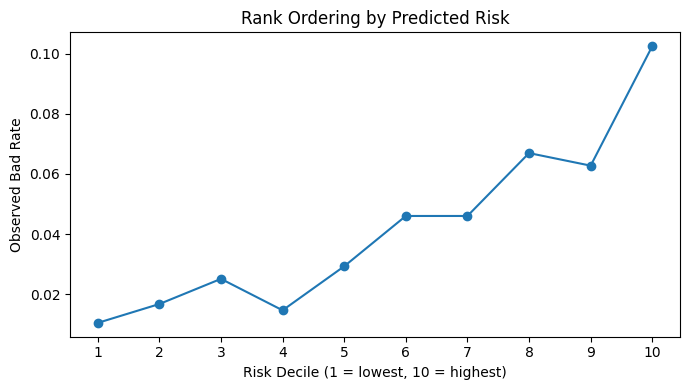

In [39]:
fig, ax = plt.subplots(figsize=(7, 4))
ordered = rank_order.sort_values("decile")
ax.plot(ordered["decile"], ordered["bad_rate"], marker="o")
ax.set_xlabel("Risk Decile (1 = lowest, 10 = highest)")
ax.set_ylabel("Observed Bad Rate")
ax.set_title("Rank Ordering by Predicted Risk")
ax.set_xticks(range(1, 11))
plt.tight_layout()
plt.show()

## 20. Out-of-time validation

The demographic reference dates span multiple months. That allows a practical temporal check:

- development period → earlier reference dates;
- out-of-time period → the final two calendar months.

This is not presented as a substitute for a formally designed production vintage study, but it is stronger than relying only on a random split.

In [40]:
valid_dates = feature_matrix["dt_opened"].dropna()

if valid_dates.nunique() > 1:
    max_month_start = valid_dates.max().to_period("M").to_timestamp()
    oot_cutoff = max_month_start - pd.offsets.MonthBegin(1)

    oot_mask = feature_matrix["dt_opened"] >= oot_cutoff
    dev_mask = feature_matrix["dt_opened"] < oot_cutoff

    print("OOT cutoff:", oot_cutoff.date())
    print("Development customers:", int(dev_mask.sum()))
    print("OOT customers        :", int(oot_mask.sum()))
    print("Development bad rate :", round(feature_matrix.loc[dev_mask, "Bad_label"].mean(), 4))
    print("OOT bad rate         :", round(feature_matrix.loc[oot_mask, "Bad_label"].mean(), 4))
else:
    oot_mask = pd.Series(False, index=feature_matrix.index)
    dev_mask = ~oot_mask
    print("Insufficient reference-date variation for OOT validation.")

OOT cutoff: 2015-11-01
Development customers: 16180
OOT customers        : 7716
Development bad rate : 0.0417
OOT bad rate         : 0.0426


In [41]:
if oot_mask.sum() > 0 and dev_mask.sum() > 0:
    X_dev = X.loc[dev_mask]
    y_dev = y.loc[dev_mask]
    X_oot = X.loc[oot_mask]
    y_oot = y.loc[oot_mask]

    oot_model = clone(best_boosting)
    oot_model.fit(X_dev, y_dev)

    dev_prob = oot_model.predict_proba(X_dev)[:, 1]
    oot_prob = oot_model.predict_proba(X_oot)[:, 1]

    oot_results = pd.DataFrame([
        evaluate_probabilities("Development", y_dev, dev_prob),
        evaluate_probabilities("Out-of-Time", y_oot, oot_prob),
    ])

    display(oot_results)

,model,ROC_AUC,Gini,KS,Average_Precision
0,Development,0.8413,0.6827,0.5190,0.2099
1,Out-of-Time,0.6750,0.3500,0.2864,0.0763


## 21. Population Stability Index (PSI)

PSI is calculated on model scores between the development and out-of-time populations.

The bins are defined from the development score distribution and then applied unchanged to the later population. PSI is a monitoring diagnostic, not a proof of causal stability.

In [42]:
def population_stability_index(expected, actual, bins=10, eps=1e-6):
    expected = np.asarray(expected, dtype=float)
    actual = np.asarray(actual, dtype=float)

    quantiles = np.linspace(0, 1, bins + 1)
    edges = np.quantile(expected, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return np.nan, pd.DataFrame()

    edges[0] = -np.inf
    edges[-1] = np.inf

    exp_bin = pd.cut(expected, bins=edges, include_lowest=True)
    act_bin = pd.cut(actual, bins=edges, include_lowest=True)

    exp_pct = pd.Series(exp_bin).value_counts(normalize=True, sort=False)
    act_pct = pd.Series(act_bin).value_counts(normalize=True, sort=False)

    idx = exp_pct.index.union(act_pct.index)
    exp_pct = exp_pct.reindex(idx, fill_value=0).clip(lower=eps)
    act_pct = act_pct.reindex(idx, fill_value=0).clip(lower=eps)

    contribution = (act_pct - exp_pct) * np.log(act_pct / exp_pct)

    detail = pd.DataFrame({
        "bin": idx.astype(str),
        "development_pct": exp_pct.values,
        "oot_pct": act_pct.values,
        "psi_component": contribution.values,
    })

    return float(contribution.sum()), detail

if oot_mask.sum() > 0 and dev_mask.sum() > 0:
    score_psi, psi_detail = population_stability_index(
        dev_prob, oot_prob, bins=10
    )

    print("Score PSI:", round(score_psi, 4))
    display(psi_detail)

Score PSI: 0.1249


,bin,development_pct,oot_pct,psi_component
0,"(-inf, 0.118]",0.1000,0.0472,0.0397
1,"(0.118, 0.154]",0.1000,0.0547,0.0273
2,"(0.154, 0.182]",0.1000,0.0700,0.0107
3,"(0.182, 0.209]",0.1000,0.0836,0.0029
4,"(0.209, 0.237]",0.1000,0.0977,0.0001
5,"(0.237, 0.269]",0.1000,0.1151,0.0021
6,"(0.269, 0.306]",0.1000,0.1161,0.0024
7,"(0.306, 0.355]",0.1000,0.1255,0.0058
8,"(0.355, 0.425]",0.1000,0.1400,0.0134
9,"(0.425, inf]",0.1000,0.1502,0.0204


### PSI interpretation guide

Common industry heuristics often use:

- PSI < 0.10 → little distribution shift
- 0.10–0.25 → moderate shift worth investigation
- > 0.25 → substantial shift

These are monitoring heuristics rather than universal regulatory thresholds.

## 22. Optional operating-threshold diagnostic

The project is primarily a ranking / scorecard exercise, so Gini, KS and rank ordering are the main outputs. A 0.50 classification threshold is shown only as a secondary diagnostic.

In a real credit decision process, the threshold should be chosen using risk appetite, expected loss, pricing, approval policy and business costs.

In [43]:
threshold = 0.50
test_pred = (boosting_test_prob >= threshold).astype(int)

print("Confusion matrix at threshold 0.50:")
print(confusion_matrix(y_test, test_pred))

print("\nClassification report:")
print(classification_report(y_test, test_pred, digits=4))

Confusion matrix at threshold 0.50:
[[4425  154]
 [ 182   19]]

Classification report:
              precision    recall  f1-score   support

           0     0.9605    0.9664    0.9634      4579
           1     0.1098    0.0945    0.1016       201

    accuracy                         0.9297      4780
   macro avg     0.5352    0.5304    0.5325      4780
weighted avg     0.9247    0.9297    0.9272      4780



## 23. EDA decisions and modeling response to the benchmark gap

In [44]:
decision_log = pd.DataFrame([
    {
        "finding": "The source data is relational with multiple account/enquiry rows per customer.",
        "decision": "Aggregate historical tables to a one-row-per-customer feature matrix."
    },
    {
        "finding": "The target is imbalanced.",
        "decision": "Use stratified validation and ranking metrics (Gini, KS, AP) rather than accuracy as the principal evidence."
    },
    {
        "finding": "The benchmark highlights 0–29 DPD behavior.",
        "decision": "Add explicit 0–29, 30–59, 60–89 and 90+ DPD bucket features, including the benchmark-aligned all-history 0–29 account indicator."
    },
    {
        "finding": "The previous Random Forest result was below the supplied 37.9% Gini benchmark.",
        "decision": "Add tuned gradient boosting, stronger DPD features, WOE/IV analysis and a transparent benchmark-gap comparison."
    },
    {
        "finding": "Credit-risk interview discussions commonly require interpretability as well as ranking power.",
        "decision": "Build a WOE/IV Logistic scorecard reference model alongside the higher-performance nonlinear model."
    },
    {
        "finding": "A single random holdout can be split-sensitive.",
        "decision": "Report final-model cross-validation mean and standard deviation and add a temporal OOT check."
    },
    {
        "finding": "Model discrimination can change when the population changes over time.",
        "decision": "Measure OOT Gini/KS and model-score PSI."
    },
    {
        "finding": "Demographic fields are anonymized.",
        "decision": "Avoid invented semantic interpretations and use generic type/cardinality rules."
    },
    {
        "finding": "The secured/unsecured purpose-code mapping is not supplied.",
        "decision": "Do not fabricate the suggested secured/unsecured enquiry ratio."
    },
])

decision_log

,finding,decision
0,The source data is relational with multiple ac...,Aggregate historical tables to a one-row-per-c...
1,The target is imbalanced.,Use stratified validation and ranking metrics ...
2,The benchmark highlights 0–29 DPD behavior.,"Add explicit 0–29, 30–59, 60–89 and 90+ DPD bu..."
3,The previous Random Forest result was below th...,"Add tuned gradient boosting, stronger DPD feat..."
4,Credit-risk interview discussions commonly req...,Build a WOE/IV Logistic scorecard reference mo...
5,A single random holdout can be split-sensitive.,Report final-model cross-validation mean and s...
6,Model discrimination can change when the popul...,Measure OOT Gini/KS and model-score PSI.
7,Demographic fields are anonymized.,Avoid invented semantic interpretations and us...
8,The secured/unsecured purpose-code mapping is ...,Do not fabricate the suggested secured/unsecur...


## 24. Final summary table

In [45]:
final_summary = pd.DataFrame({
    "item": [
        "Best holdout model",
        "Holdout ROC-AUC",
        "Holdout Gini",
        "Holdout KS",
        "Holdout Average Precision",
        "Benchmark Gini",
        "Gini gap vs benchmark",
        "Final CV ROC-AUC mean",
        "Final CV ROC-AUC std",
        "Final CV Gini mean",
        "WOE selected features",
        "Implemented benchmark-suggested features",
    ],
    "value": [
        f"Tuned {BOOSTING_BACKEND}",
        boosting_eval["ROC_AUC"],
        boosting_eval["Gini"],
        boosting_eval["KS"],
        boosting_eval["Average_Precision"],
        BENCHMARK_GINI,
        boosting_eval["Gini"] - BENCHMARK_GINI,
        final_cv_auc_mean,
        final_cv_auc_std,
        gini_from_auc(final_cv_auc_mean),
        len(selected_woe_features),
        len(present),
    ],
})

final_summary

,item,value
0,Best holdout model,Tuned XGBoost
1,Holdout ROC-AUC,0.6843
2,Holdout Gini,0.3685
3,Holdout KS,0.2865
4,Holdout Average Precision,0.0821
5,Benchmark Gini,0.3790
6,Gini gap vs benchmark,-0.0105
7,Final CV ROC-AUC mean,0.6840
8,Final CV ROC-AUC std,0.0226
9,Final CV Gini mean,0.3680


## 25. Final conclusion

This notebook directly addresses the requested project outputs and the main weaknesses of the earlier version.

### What improved

**Feature engineering**
- The benchmark-aligned `payment_history_avg_dpd_0_29_bucket` is explicitly implemented.
- Payment history is expanded into 0–29, 30–59, 60–89 and 90+ DPD buckets.
- Account utilization, balance/limit ratios and enquiry recency remain part of the feature matrix.

**Credit-risk methodology**
- WOE and IV are calculated on the training population.
- A WOE Logistic scorecard is evaluated as an interpretable reference model.
- KS is reported together with AUC, Gini and Average Precision.
- Rank ordering includes cumulative bad/good distributions and decile KS.

**Model performance**
- Gradient boosting is tuned over a meaningful search space rather than a minimal four-trial search.
- The tuned model is explicitly compared with the supplied 37.9% Gini benchmark.
- If the benchmark is still not exceeded, the gap is reported honestly and tied to concrete next investigations rather than hidden.

**Validation and stability**
- The final model reports cross-validation mean and standard deviation.
- A chronological out-of-time check is performed when the reference-date coverage permits it.
- PSI is calculated on development versus OOT model-score distributions.

### Remaining limitations

- The demographic variables are anonymized, which limits business interpretation.
- The project brief does not provide the purpose-code mapping needed to derive the suggested secured/unsecured enquiry ratio.
- The original benchmark's exact data split, preprocessing and implementation are not supplied, so identical Gini cannot be guaranteed.
- A production credit model would require independent validation, governance, fairness testing, calibration review, stability monitoring and policy approval before use.

The final model should therefore be judged on both **discrimination** and **defensibility**: benchmark comparison, Gini, KS, rank ordering, WOE/IV interpretability, and temporal stability are all reported rather than relying on a single accuracy number.